h = 0.01
average y = 1.9108274251454211
y near 15 = 0.23143958278769802
average error = 0.36859275343186826
local error near 15 = 0.04093536420886787

h = 0.05
average y = 1.018602145456671
y near 15 = 0.11986884462031855
average error = 1.259613980794064
local error near 15 = 0.15250610237639356

h = 0.1
average y = 0.5380678135269734
y near 15 = 0.05131833580208075
average error = 1.7381438051572906
local error near 15 = 0.22105661119458356

h = 0.15000000000000002
average y = 0.32050525982522327
y near 15 = 0.020921338696345992
average error = 1.955839479439368
local error near 15 = 0.25145360830034413

h = 0.2
average y = 0.20456814776837254
y near 15 = 0.007903260555351045
average error = 2.067650935655412
local error near 15 = 0.2644716864413199

h = 0.25
average y = 0.13633523621413834
y near 15 = 0.0026622902905731154
average error = 2.1402882314396856
local error near 15 = 0.26971265670610667

h = 0.3
average y = 0.09160157795514352
y near 15 = 0.0007534138886943617
average er

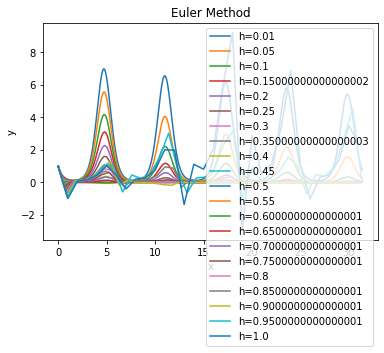

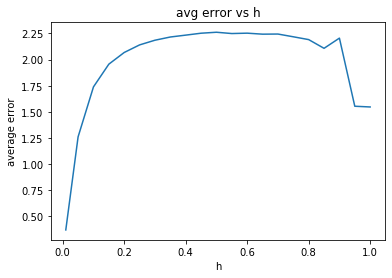

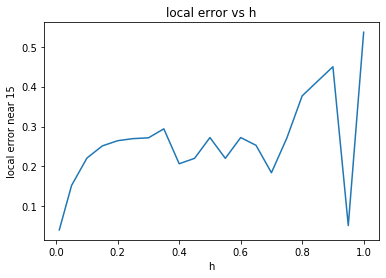

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def f(x, y):
    return -2 * y * np.cos(x)

def exact(x):
    return np.exp(-2 * np.sin(x))

h_list = [0.01] + list(np.arange(0.05, 1.01, 0.05))

x0 = 0
x_end = 10 * np.pi

avg_error_list = []
local_error_list = []

plt.figure()

for h in h_list:

    steps = int((x_end - x0) / h)

    x = [0] * (steps + 1)
    y = [0] * (steps + 1)

    x[0] = x0
    y[0] = 1

    for i in range(steps):
        x[i+1] = x[i] + h
        y[i+1] = y[i] + h * f(x[i], y[i])

    x = np.array(x)
    y = np.array(y)

    y_real = exact(x)

    error = abs(y - y_real)

    avg_y = sum(y) / len(y)
    avg_error = sum(error) / len(error)

    index = 0
    smallest = abs(x[0] - 15)

    for i in range(len(x)):
        if abs(x[i] - 15) < smallest:
            smallest = abs(x[i] - 15)
            index = i

    y_15 = y[index]
    y_15_real = exact(x[index])

    local_error = abs(y_15 - y_15_real)

    avg_error_list.append(avg_error)
    local_error_list.append(local_error)

    print("h =", h)
    print("average y =", avg_y)
    print("y near 15 =", y_15)
    print("average error =", avg_error)
    print("local error near 15 =", local_error)
    print()

    plt.plot(x, y, label="h=" + str(h))

plt.xlabel("x")
plt.ylabel("y")
plt.title("Euler Method")
plt.legend()
plt.show()

plt.figure()
plt.plot(h_list, avg_error_list)
plt.xlabel("h")
plt.ylabel("average error")
plt.title("avg error vs h")
plt.show()

plt.figure()
plt.plot(h_list, local_error_list)
plt.xlabel("h")
plt.ylabel("local error near 15")
plt.title("local error vs h")
plt.show()